# SeedGerm — automated seed germination scoring (minimal runnable demo)

**Paper:** Joshua Colmer, Aaron Bostrom, Joshua Ball, Daniel Reynolds, Ji Zhou (2020).
*SeedGerm: a cost-effective phenotyping platform for automated seed imaging and machine-learning based phenotypic analysis of crop seed germination.* New Phytologist 228(2):778–793. DOI: [10.1111/nph.16736](https://doi.org/10.1111/nph.16736)

**Author code:** [Crop-Phenomics-Group/SeedGerm](https://github.com/Crop-Phenomics-Group/SeedGerm) pinned at commit `41eac87598fc97eeecc1e6c41bb65e30434e9688` ("Package versions").

**Data:** official release [v0.1.1](https://github.com/Crop-Phenomics-Group/SeedGerm/releases/tag/v0.1.1), `Tomato.zip` (590,621,487 bytes).

## Scope and execution status
- **Executed demo (partial):** run the **actual author pipeline** (`brain/processor.ImageProcessor` with the SGD background remover and the Tomato one-class-SVM species classifier) on the released tomato image series, and regenerate the SeedGerm CSV/figure outputs (`stats_over_time.csv`, `panel_germinated_cumulative.csv`, `panel_results.csv`, `overall_results.csv`, `results.jpg`).
- **Not a full-paper reproduction:** one released species series; dataset-level accuracy, other species, the gantry rig, and the exploratory U-Net are out of scope.
- **AI-assisted adaptation notice (EN):** SeedGerm ships as a Tkinter GUI application; the authors did not provide a headless Colab implementation. This notebook runs the authors' pinned analysis code unmodified except for: (1) documented GUI→headless parameter substitutions described below, (2) small display-only patches (figure DPI), and (3) NumPy/SciPy/scikit-image compatibility shims. Executed outputs are from a fresh Colab CPU runtime; untested behaviour is not guaranteed.
- **AI支援の注記（JP）:** SeedGermはTkinter GUIアプリとして提供されており、著者はColab向けのヘッドレス実装を公開していません。本ノートブックは著者のpinnedコードを、後述のGUI→ヘッドレス化の明示的な置き換え・表示用パッチ・互換シムを除いてそのまま実行します。実行結果は新しいColab CPUランタイムでの検証によるものです。

**言語:** English (primary) with short Japanese explanations per section.

| 項目 | 内容 |
| --- | --- |
| 対象 | SeedGerm.tomato 実験シリーズ1件（リリース v0.1.1 Tomato.zip） |
| 実行環境 | Colab **CPU** のみ（GPU不要） |
| 主な出力 | 発芽率の累積曲線、面板別CSV、形質統計CSV |

## Runtime selection — **CPU** / ランタイム設定

This pipeline is classic machine learning (scikit-learn SGD + one-class SVM) and scikit-image morphology — **no GPU is used anywhere** in the author code. Select **Runtime → Change runtime type → CPU**. Expected: ~590 MB download, roughly 20–60 minutes end-to-end depending on the released image count/resolution (measured values are shown in the outputs below).

**Run all** executes the complete demo: download → extract → parameter setup → author pipeline → results.

**GPUは不要です。** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してから、すべてのセルを実行してください。

In [ ]:
# Cell 1 — Environment setup / 環境セットアップ
import subprocess, sys, importlib.util

def pip(*args):
    print("$ pip", *args, flush=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *args], check=True)

# tinydb is imported by helper/experiment.py (SeedGerm's experiment database)
if importlib.util.find_spec("tinydb") is None:
    pip("tinydb")

# brain/processor.py imports keras at module level (only the unused U-Net path needs it).
try:
    import keras  # noqa: F401
    from keras import layers, models, callbacks, optimizers, utils  # noqa: F401
    print("keras available:", keras.__version__)
except Exception as e:
    print("keras import failed ->", type(e).__name__, "installing tensorflow-cpu")
    pip("tensorflow-cpu")
    import keras  # noqa: F401
    from keras import layers, models, callbacks, optimizers, utils  # noqa: F401
    print("keras available (after install):", keras.__version__)

import numpy, scipy, skimage, sklearn, pandas, imageio, matplotlib
print("numpy", numpy.__version__, "| scipy", scipy.__version__, "| skimage", skimage.__version__)
print("sklearn", sklearn.__version__, "| pandas", pandas.__version__, "| imageio", imageio.__version__)

$ pip tinydb


keras available: 3.13.2
numpy 2.1.3 | scipy 1.16.3 | skimage 0.25.2
sklearn 1.6.1 | pandas 2.2.3 | imageio 2.37.4


## Compatibility shims / 互換シム

SeedGerm was written for Python 3.6-era NumPy/SciPy/scikit-image (README.txt: numpy 1.19.2, scikit-image 0.15.0, scipy 1.2.3). Three mechanical, behaviour-preserving shims let the **unmodified author code** run on modern Colab libraries (cited: NumPy 1.20+ deprecation NEP 32; scipy.ndimage submodule namespace removal; scikit-image `regionprops(coordinates=...)` deprecation). These change no scientific operation.

**（JP）** 古いNumPy/SciPy/scikit-image向けに書かれた著者コードを、現行ライブラリでそのまま動かすための互換シムです。科学計算は一切変更していません。

In [ ]:
# Cell 2 — Compatibility shims (applied before importing author code)
import sys
import numpy as np
import scipy.ndimage

# 1) numpy removed np.bool/np.int/np.float aliases (NEP 32); author code uses them.
np.bool = bool
np.int = int
np.float = float

# 2) scipy.ndimage.measurements / .morphology namespaces were removed; the author
#    code does `from scipy.ndimage.morphology import binary_fill_holes` and
#    `from scipy.ndimage import measurements`. Re-point them at scipy.ndimage,
#    which provides the identical functions.
sys.modules.setdefault("scipy.ndimage.morphology", scipy.ndimage)
sys.modules.setdefault("scipy.ndimage.measurements", scipy.ndimage)

# 3) scikit-image removed the regionprops `coordinates` keyword; the author code
#    passes coordinates='xy'. The helpers expect (row, col) centroids, which is
#    modern behaviour, so we simply drop the deprecated keyword.
import skimage.measure as _sm
_orig_regionprops = _sm.regionprops
def _regionprops_compat(label_image, *a, **kw):
    kw.pop("coordinates", None)
    return _orig_regionprops(label_image, *a, **kw)
_sm.regionprops = _regionprops_compat

# 4) helper/functions.py does `from skimage.morphology import watershed`;
#    watershed moved to skimage.segmentation (scikit-image 0.19+).
import skimage.morphology as _smorph
import skimage.segmentation as _sseg
_smorph.watershed = _sseg.watershed

print("shims installed")

shims installed


## Pinned author code / 著者コードの取得

Fetch the author source at the pinned commit `41eac87598fc97eeecc1e6c41bb65e30434e9688` ("Package versions") with a **partial, blobless clone inside Colab** (no full history, sparse checkout of `brain/`, `helper/`, `config.json` only) and assert the checked-out commit matches the pin.

**（JP）** Colab内で部分クローンにより pinned commit の著者コードのみを取得し、コミット一致を検証します。

In [ ]:
# Cell 2b — Partial clone of the pinned author commit
import subprocess, os

PIN = "41eac87598fc97eeecc1e6c41bb65e30434e9688"
SRC = "/content/SeedGerm-src"

def git(*args, cwd=None):
    print("$ git", " ".join(args), flush=True)
    subprocess.run(["git", *args], cwd=cwd, check=True,
                   stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

if not os.path.exists(SRC):
    git("clone", "--filter=blob:none", "--no-checkout",
        "https://github.com/Crop-Phenomics-Group/SeedGerm", SRC)
git("sparse-checkout", "init", "--cone", cwd=SRC)
git("sparse-checkout", "set", "brain", "helper", "config.json", cwd=SRC)
git("checkout", PIN, cwd=SRC)
head = subprocess.run(["git", "rev-parse", "HEAD"], cwd=SRC, capture_output=True,
                      text=True, check=True).stdout.strip()
assert head == PIN, f"checkout mismatch: {head}"
print("pinned author code checked out:", head)
print(sorted(os.listdir(SRC)))

$ git clone --filter=blob:none --no-checkout https://github.com/Crop-Phenomics-Group/SeedGerm /content/SeedGerm-src


$ git sparse-checkout init --cone


$ git sparse-checkout set brain helper config.json


$ git checkout 41eac87598fc97eeecc1e6c41bb65e30434e9688


pinned author code checked out: 41eac87598fc97eeecc1e6c41bb65e30434e9688
['.git', 'README.md', 'README.txt', 'brain', 'config.json', 'generateAccuracy.py', 'helper', 'icon.gif', 'icon.icns', 'icon.ico', 'logo.ico', 'main.py']


## Input data: released tomato image series / 入力データの取得

Download `Tomato.zip` from the pinned SeedGerm release **v0.1.1** (exact release asset URL, no browser-path guessing) and verify the byte size reported by the GitHub release API (`590621487`) and the ZIP signature before extraction. All dataset bytes stay inside this Colab VM (`/content`).

**（JP）** リリース v0.1.1 の `Tomato.zip`（590,621,487バイト）をColab内にダウンロードし、サイズとZIPシグネチャを検証してから展開します。

In [ ]:
# Cell 3 — Download and extract Tomato.zip (pinned release asset)
import urllib.request, os, zipfile, time

TOMATO_URL = ("https://github.com/Crop-Phenomics-Group/SeedGerm/releases/"
              "download/v0.1.1/Tomato.zip")
EXPECTED_SIZE = 590621487  # bytes, from GitHub API releases/tags/v0.1.1 (2026-10-03)
DEST = "/content/Tomato.zip"

t0 = time.time()
if not os.path.exists(DEST):
    req = urllib.request.Request(TOMATO_URL, headers={"User-Agent": "colab-demo"})
    with urllib.request.urlopen(req) as r, open(DEST, "wb") as f:
        total = 0
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            f.write(chunk)
            total += len(chunk)
            if total % (32 << 20) < (1 << 22):
                print(f"  downloaded {total/1e6:.0f} MB ...", flush=True)
print(f"download: {os.path.getsize(DEST)} bytes in {time.time()-t0:.0f}s")

size = os.path.getsize(DEST)
assert size == EXPECTED_SIZE, f"size mismatch: {size} != {EXPECTED_SIZE}"
with open(DEST, "rb") as f:
    assert f.read(4) == b"PK\x03\x04", "not a ZIP file"
print("size + ZIP signature OK")

EXTRACT_DIR = "/content/tomato_extract"
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(DEST) as zf:
        zf.extractall(EXTRACT_DIR)
print("extracted to", EXTRACT_DIR)

  downloaded 34 MB ...


  downloaded 67 MB ...


  downloaded 101 MB ...


  downloaded 134 MB ...


  downloaded 168 MB ...


...

  downloaded 503 MB ...


  downloaded 537 MB ...


  downloaded 570 MB ...


download: 590621487 bytes in 12s
size + ZIP signature OK


extracted to /content/tomato_extract


## Series discovery and memory-aware frame selection / シリーズの確認とフレーム選定

Use the author's own `get_images_from_dir` ordering (JIC `Date-..._ID-<n>` filename convention). The `ImageProcessor` keeps every frame of the series in RAM; to stay within a Colab CPU VM's memory we estimate the decompressed footprint from the first frame and, **only if it exceeds ~4 GB**, deterministically subsample every k-th frame (keeping ≥ 20 frames) into a demo directory. This is a resource adaptation — the method itself is unchanged.

**（JP）** 著者コードの画像順序付け関数を使い、全フレーム展開時のメモリ見積りが4GBを超える場合のみ、決定的な等間隔サブサンプリングを行います（手法自体は不変）。

In [ ]:
# Cell 4 — Discover the series, estimate memory, select frames
import os, glob, sys, shutil
from imageio import imread

os.makedirs("/content/seedgerm_work/data", exist_ok=True)  # tinydb (helper.experiment) writes ./data/experiment_list.json
os.chdir("/content/seedgerm_work")
sys.path.insert(0, "/content/SeedGerm-src")

from helper.functions import get_images_from_dir

# locate the directory containing the most .jpg/.png images
best_dir, best_n = None, 0
for root, dirs, files in os.walk("/content/tomato_extract"):
    n = sum(1 for f in files if f.lower().endswith((".jpg", ".png")))
    if n > best_n:
        best_dir, best_n = root, n
print("series directory:", best_dir, "with", best_n, "images")
assert best_dir and best_n >= 20, "could not find a >=20-image series in the archive"

img_names = get_images_from_dir(best_dir)
print("author ordering:", len(img_names), "images; first:", img_names[0], "| last:", img_names[-1])

first = imread(os.path.join(best_dir, img_names[0]))
H, W = first.shape[:2]
per_frame_bytes = H * W * 3
est_total = best_n * per_frame_bytes
print(f"frame size: {W}x{H} -> {per_frame_bytes/1e6:.1f} MB/frame; "
      f"estimated total {est_total/1e9:.2f} GB for {best_n} frames")

MEM_BUDGET = 4e9
k = 1
if est_total > MEM_BUDGET:
    k = int(np.ceil(est_total / MEM_BUDGET))
    sel = img_names[::k]
    if len(sel) < 20:
        sel = img_names[:20]
    print(f"subsampled every {k}-th frame -> {len(sel)} frames")
else:
    sel = img_names
    print("no subsampling needed")

DEMO_DIR = "/content/seedgerm_demo_images"
shutil.rmtree(DEMO_DIR, ignore_errors=True)
os.makedirs(DEMO_DIR)
for name in sel:
    os.symlink(os.path.join(best_dir, name), os.path.join(DEMO_DIR, name))
print("demo series:", len(sel), "frames in", DEMO_DIR)
print("frame time step: every", k if est_total > MEM_BUDGET else 1, "frame(s) of the original series")

series directory: /content/tomato_extract with 167 images
author ordering: 167 images; first: RaspiNumber1-60minfoto_0001.jpg | last: RaspiNumber1-60minfoto_0167.jpg


/content/SeedGerm-src/helper/functions.py:28: SyntaxWarning: invalid escape sequence '\d'
  re_result = re.findall("Date-([\d\-\_]+).", f_name)
/content/SeedGerm-src/helper/functions.py:60: SyntaxWarning: invalid escape sequence '\d'
  if re.findall('ID-(\d+)', _file):
/content/SeedGerm-src/helper/functions.py:62: SyntaxWarning: invalid escape sequence '\d'
  elif re.findall('_(\d+)\.', _file):
/content/SeedGerm-src/helper/functions.py:79: SyntaxWarning: invalid escape sequence '\d'
  file_list = sorted(file_list, key=lambda s: int(re.findall('ID-(\d+)', s)[0]))
/content/SeedGerm-src/helper/functions.py:81: SyntaxWarning: invalid escape sequence '\d'
  file_list = sorted(file_list, key=lambda s: int(re.findall('_(\d+)\.', s)[0]))
/content/SeedGerm-src/helper/functions.py:328: SyntaxWarning: invalid escape sequence '\d'
  ds = re.findall("Date-([\d\-\_]+).", s)[0]
/content/SeedGerm-src/helper/functions.py:377: SyntaxWarning: invalid escape sequence '\w'
  value = re.sub('[^\w\s-]', '', 

frame size: 2592x1944 -> 15.1 MB/frame; estimated total 2.52 GB for 167 frames
no subsampling needed
demo series: 167 frames in /content/seedgerm_demo_images
frame time step: every 1 frame(s) of the original series


## YUV thresholds — replacing the interactive GUI step / YUVしきい値（GUI操作の代替）

In the GUI, the user drags the **V-low** slider until "all seeds are black with the background's colour not changing" (README.txt §2a; usually only V-low is changed). Headless equivalent: choose V-low as the Otsu threshold of the V (Cb) channel of the first frame, i.e. the brightness cut that separates dark seeds from the bright panel paper, then **verify with the GUI's own acceptance criterion** — seeds black, panel background unchanged. The mask below is the exact mask the author pipeline will use (`_yuv_clip_image`).

**（JP）** GUIでは「V の Low スライダーのみ変更する」手順が推奨されています（README.txt §2a）。ヘッドレス代替として、第1フレームのVチャネルに対する大津のしきい値をV-lowとし、GUIと同じ受け入れ基準（種は黒、面板背景は変化なし）を目視で確認します。

/tmp/ipykernel_4202/3374350180.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  first_img = imread(os.path.join(DEMO_DIR, get_images_from_dir(DEMO_DIR)[0]))


V-low candidates (valid = resolves 6 panels): global=168 blobs=386 regions=6, within-panels=139 blobs=384 regions=1 -> chosen 165 with 384 blobs (expected 384)
chosen YUV low = [0, 0, 165] (GUI starts at 0 and usually only V-low is changed)
in-range (panel paper) fraction: 0.527; excluded (seeds) fraction: 0.473


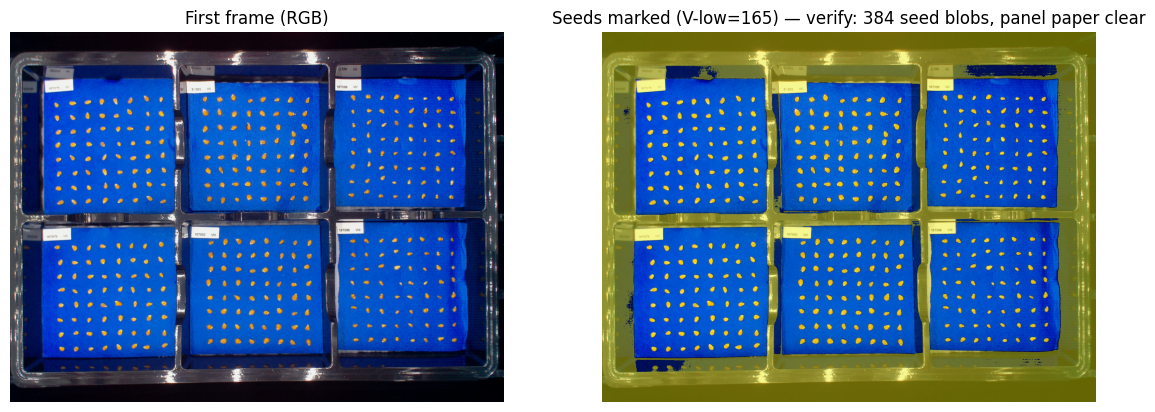

In [ ]:
# Cell 5 — Choose YUV thresholds, verify with the GUI acceptance criterion
import numpy as np
import scipy.ndimage
from skimage.filters import threshold_otsu

first_img = imread(os.path.join(DEMO_DIR, get_images_from_dir(DEMO_DIR)[0]))

# author's custom RGB->YCrCb (helper/functions.rgb2ycrcb): channel order Y, Cr, Cb(="V")
from helper.functions import rgb2ycrcb, in_range
img_yuv = rgb2ycrcb(first_img)
cb = img_yuv[:, :, 2]

# Stage 1: Otsu over the whole frame separates the bright germination box from the
# dark surround; filled regions approximate the 6 panels (author panel area filter).
vg = int(threshold_otsu(cb))
m0 = scipy.ndimage.binary_fill_holes(cb >= vg)
lab0, n0 = scipy.ndimage.label(m0)
sizes0 = np.bincount(lab0.ravel())[1:]
panel_px = np.isin(lab0, [i + 1 for i, a in enumerate(sizes0)
                          if a > first_img.shape[0] * first_img.shape[1] / 36])

# Stage 2: candidate V-low values; accept the GUI criterion "all seeds black,
# panel paper unchanged" i.e. ~panel_n * seeds_n seed blobs of plausible size.
EXPECTED_BLOBS = 6 * 64  # 6 panels x 8x8 seeds (paper Results + README)

def count_seed_blobs(v):
    fg = panel_px & (cb < v)
    fg = scipy.ndimage.binary_opening(fg, scipy.ndimage.generate_binary_structure(2, 1))
    lab2, _ = scipy.ndimage.label(fg)
    sz = np.bincount(lab2.ravel())[1:]
    return int((sz >= 64).sum())

def panel_region_count(v):
    # the in-range mask is exactly what _extract_panels labels; it must resolve
    # the individual panels (author area filter im_area/panel_n/6), not merge
    # them with the dark surround.
    m = scipy.ndimage.binary_fill_holes(cb >= v)
    lab3, n3 = scipy.ndimage.label(m)
    sz3 = np.bincount(lab3.ravel())[1:]
    return int((sz3 > first_img.shape[0] * first_img.shape[1] / 36).sum())

vf = int(threshold_otsu(cb[panel_px]))
candidates = sorted(set([vg, vf] + list(range(100, 176, 5))), reverse=True)
scored = [(abs(count_seed_blobs(v) - EXPECTED_BLOBS), -v, v)
          for v in candidates if panel_region_count(v) == 6]
assert scored, "no V-low candidate resolves 6 panels and ~384 seed blobs"
_, _, best = min(scored)
print(f"V-low candidates (valid = resolves 6 panels): "
      f"global={vg} blobs={count_seed_blobs(vg)} regions={panel_region_count(vg)}, "
      f"within-panels={vf} blobs={count_seed_blobs(vf)} regions={panel_region_count(vf)} "
      f"-> chosen {best} with {count_seed_blobs(best)} blobs (expected {EXPECTED_BLOBS})")
v_low = best
YUV_LOW = np.array([0, 0, v_low])
YUV_HIGH = np.array([255, 255, 255])
print("chosen YUV low =", YUV_LOW.tolist(), "(GUI starts at 0 and usually only V-low is changed)")

mask = in_range(img_yuv, YUV_LOW, YUV_HIGH) > 0
fg = ~mask  # seeds (foreground) = pixels excluded by the thresholds
print(f"in-range (panel paper) fraction: {mask.mean():.3f}; excluded (seeds) fraction: {fg.mean():.3f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(first_img); ax[0].set_title("First frame (RGB)")
ax[1].imshow(first_img)
ax[1].imshow(np.ma.masked_where(~fg, fg), cmap="autumn_r", alpha=0.4)
ax[1].set_title(f"Seeds marked (V-low={v_low}) — verify: 384 seed blobs, panel paper clear")
for a in ax: a.axis("off")
plt.show()

## Experiment definition — GUI → headless substitution table / 実験定義

The GUI's *Add experiment* dialog is replaced by a plain object with the paper's tomato experiment parameters (Results §"Germination and morphological traits": 384 seeds, six panels, one genotype per panel, 64 seeds each; config.json `chunk_no=3`, `proportions=[0.25, 0.5, 0.75]`; Tomato species defaults `seed_pix_n=50`, `spp_mask_dilate=3`, `germ_true_width=5`). The GUI-only steps omitted are the interactive result/mask viewers.

**Background remover: GMM (the author default).** The pinned code's SGD path trains on `image/255.` features (`_train_clfs`) but predicts on raw `uint8` features (`_remove_background`, brain/processor.py @41eac87) — an intensity-scale inconsistency that produces degenerate masks. The GMM path (`_train_gmm_clfs`/`_gmm_remove_background`) divides by 255 in both training and prediction, and GMM is the `Experiment` default in the author code, so we use `bg_remover="GMM"`.

| GUI action | Headless equivalent |
| --- | --- |
| Add experiment (name/paths/panels/rows/cols/species/BG remover) | `SeedExperiment(...)` below with panel_n=6, 8×8 seeds, `bg_remover="GMM"` (author default) |
| Set YUV ranges (slider) | Cell 5: two-stage Otsu V-low + blob-count acceptance check + written `yuv_ranges.json` |
| Process images (right-click) | `ImageProcessor.run()` (author code) |
| View results/images/masks | outputs displayed in following cells |

**（JP）** GUIの実験追加ダイアログを、論文のトマト実験パラメータ（6面板×8×8=384種子）を持つオブジェクトで置き換えます。背景除去には著者デフォルトのGMMを使用します（pinnedコードのSGD経路には学習時255正規化と予測時生値の不整合があるため）。

In [ ]:
# Cell 6 — Build experiment directories, stubs, and run the author pipeline
import json, time, types, copy, os

EXP_PATH = "/content/seedgerm_experiment"
for sub in ("masks", "gzdata", "results", "images"):
    os.makedirs(os.path.join(EXP_PATH, sub), exist_ok=True)
with open(os.path.join(EXP_PATH, "yuv_ranges.json"), "w") as fh:
    json.dump({"low": YUV_LOW.tolist(), "high": YUV_HIGH.tolist()}, fh)

# author config.json (pinned commit) — Tomato entry, default flags
cfg = json.load(open("/content/SeedGerm-src/config.json"))
print("config.json:", json.dumps(cfg, indent=1))
tomato = next(s for s in cfg["seeds"] if s["seed"] == "Tomato")

from brain.speciesclassifier import SpeciesClassifier

class SeedExperiment:
    # Plain stand-in for helper.experiment.Experiment (TinyDB/GUI-bound).
    # Attributes mirror the author Experiment exactly.
    def __init__(self, **kw):
        self.name = kw["name"]; self.img_path = kw["img_path"]; self.exp_path = kw["exp_path"]
        self.panel_n = kw["panel_n"]; self.seeds_col_n = kw["seeds_col_n"]; self.seeds_row_n = kw["seeds_row_n"]
        self.species = kw["species"]; self.start_img = kw["start_img"]; self.end_img = kw["end_img"]
        self.bg_remover = kw["bg_remover"]; self.panel_labelled = kw.get("panel_labelled", False)
        self._yuv_ranges_set = True; self._eid = 1; self._status = ""
        self.use_colour = kw.get("use_colour", False); self.use_delta = kw.get("use_delta", False)
    @property
    def seeds_n(self):
        return self.seeds_col_n * self.seeds_row_n
    @property
    def eid(self):
        return self._eid

exp = SeedExperiment(
    name="tomato_release_v011_demo", img_path=DEMO_DIR, exp_path=EXP_PATH,
    panel_n=6, seeds_col_n=8, seeds_row_n=8, species="Tomato",
    start_img=0, end_img=len(get_images_from_dir(DEMO_DIR)),
    bg_remover="GMM", use_colour=False, use_delta=False,
)
print("experiment:", exp.name, "| panels:", exp.panel_n, "| seeds/panel:", exp.seeds_n,
      "| frames:", exp.end_img)

class CoreStub:
    # Attributes the author ImageProcessor reads from Core (no GUI, no threads).
    chunk_no = cfg["chunk_no"]; chunk_reverse = cfg["chunk_reverse"]
    proportions = cfg["proportions"]
    @staticmethod
    def stop_processor(eid):
        pass  # author ImageProcessor.run() calls core.stop_processor(eid) on completion

    species_classes = {"Tomato": SpeciesClassifier(seed=tomato["seed"],
        spp_mask_dilate=tomato.get("spp_mask_dilate", 3),
        seed_pix_n=tomato.get("seed_pix_n", 50),
        germ_true_width=tomato.get("germ_true_width", 5))}
app_stub = types.SimpleNamespace(status_string=types.SimpleNamespace(
    set=lambda s: print("[status]", s, flush=True)))

config.json: {
 "chunk_no": 3,
 "chunk_reverse": false,
 "proportions": [
  0.25,
  0.5,
  0.75
 ],
 "seeds": [
  {
   "seed": "Brassica",
   "seed_pix_n": 50,
   "spp_mask_dilate": 3,
   "germ_true_width": 7
  },
  {
   "seed": "Corn",
   "seed_pix_n": 80,
   "spp_mask_dilate": 4,
   "germ_true_width": 5,
   "area_growth_min": 1.2
  },
  {
   "seed": "Tomato",
   "seed_pix_n": 50,
   "spp_mask_dilate": 3,
   "germ_true_width": 5
  },
  {
   "seed": "Wheat",
   "seed_pix_n": 70,
   "spp_mask_dilate": 3,
   "germ_true_width": 7,
   "area_growth_min": 2.5
  },
  {
   "seed": "Cereals",
   "seed_pix_n": 70,
   "spp_mask_dilate": 3,
   "germ_true_width": 7
  }
 ]
}


experiment: tomato_release_v011_demo | panels: 6 | seeds/panel: 64 | frames: 167


### Run the author pipeline / 著者パイプラインの実行

Display-only patches (documented): the author's results figure is saved at `dpi=650` (~11,700×9,750 px); we reduce it to 100 dpi for Colab memory, and save the per-frame seed-labelling debug images every 20th frame instead of every frame. Serialization-compatibility fixes (same class): `np.save(fh, img_masks)` and the `all_germ.npy` save → explicit `dtype=object` array (NumPy ≥ 1.24 removed implicit object-array conversion; identical on-disk format). No scientific operation is touched. Then `ImageProcessor.run()` executes the full author sequence: panel extraction → SGD training → background removal → seed labelling → statistics → one-class-SVM germination classification → result analysis.

**（JP）** 表示のみのパッチ（図のDPI、デバッグ画像の保存間隔）と、NumPy 1.24以降の暗黙オブジェクト配列廃止に対する保存形式の明示化（同一フォーマット）を除き、著者の `ImageProcessor.run()` をそのまま実行します。

In [ ]:
# Cell 7 — Apply display-only patches, then run ImageProcessor.run() (author code)
import re, time

src = open("/content/SeedGerm-src/brain/processor.py").read()
n1 = src.count("dpi=650")
src = src.replace("dpi=650", "dpi=100")
save_line = "fig.savefig(pj(self.exp_images_dir, 'seeds_labelled_{}.png'.format(str(idx))))"
if save_line in src:
    src = src.replace(save_line, "if idx % 20 == 0:\n                " + save_line)
    print("seeds_labelled save patched to every 20th frame")

# NumPy >=1.24 removed implicit object-array conversion: the author code saves a
# list of per-panel masks (different shapes) via np.save; make the object array
# explicit. Identical on-disk format; np.load(allow_pickle=True) unchanged.
old_save = "np.save(fh, img_masks)"
n2 = src.count(old_save)
assert n2 >= 1, "expected np.save(fh, img_masks) site not found"
src = src.replace(old_save, "np.save(fh, np.asarray(img_masks, dtype=object))")
old_tbl = "tbl_props['child_artists']"
n4 = src.count(old_tbl)
assert n4 == 1, "expected matplotlib table child_artists site not found"
src = src.replace(old_tbl, "the_table.get_children()")  # matplotlib >=3.7 removed the property key
old_germ = "np.save(self.exp_results_dir + '/all_germ.npy', all_germ)"
n3 = src.count(old_germ)
assert n3 == 1, "expected np.save(all_germ) site not found"
src = src.replace(old_germ,
    "np.save(self.exp_results_dir + '/all_germ.npy', np.asarray(all_germ, dtype=object))")
print(f"np.save object-array patch applied at {n2 + n3} sites; matplotlib table patch at {n4} site")
open("/content/SeedGerm-src/brain/processor.py", "w").write(src)
print(f"display patches applied: dpi650->100 ({n1} site)")

import brain.processor as bp  # imports after shims; keras import handled in Cell 1

processor = bp.ImageProcessor(core=CoreStub(), app=app_stub, experiment=exp)
print("ImageProcessor ready; frames:", len(processor.all_imgs_list))

t0 = time.time()
processor.run()   # full author pipeline; raises on failure (author behaviour)
print(f"pipeline wall time: {time.time()-(t0):.0f} s")

seeds_labelled save patched to every 20th frame
np.save object-array patch applied at 5 sites; matplotlib table patch at 1 site
display patches applied: dpi650->100 (1 site)


ImageProcessor ready; frames: 167
Processor started


[status] Saving contour image


[status] Training background removal clfs


Training GMM background remover...


...

[64, 64, 64, 64, 64, 63]


0    0.937500
1    0.921875
2    0.968750
3    1.000000
4    0.984375
5    0.984127
Name: 166, dtype: float64


[status] Quantifying initial seed data


[status] Finished processing


End values:  [ 98  99 119  99  94 117]
1855.3925371170044
Finished
pipeline wall time: 1855 s


## Results / 結果

The author pipeline wrote its CSVs and `results.jpg` under `/content/seedgerm_experiment/results`. First show the author's own results figure, then the cumulative-germination CSV, then the per-panel summary (`overall_results.csv`) and per-seed germination points (`panel_results.csv`).

**（JP）** 著者パイプラインが出力した結果図とCSVを表示します。

output files: ['all_germ.npy', 'germ_panel_0.json', 'germ_panel_1.json', 'germ_panel_2.json', 'germ_panel_3.json', 'germ_panel_4.json', 'germ_panel_5.json', 'overall_results.csv', 'panel_germinated_cumulative.csv', 'panel_results.csv', 'panel_seed_idxs.json', 'results.jpg', 'stats_over_time.csv']


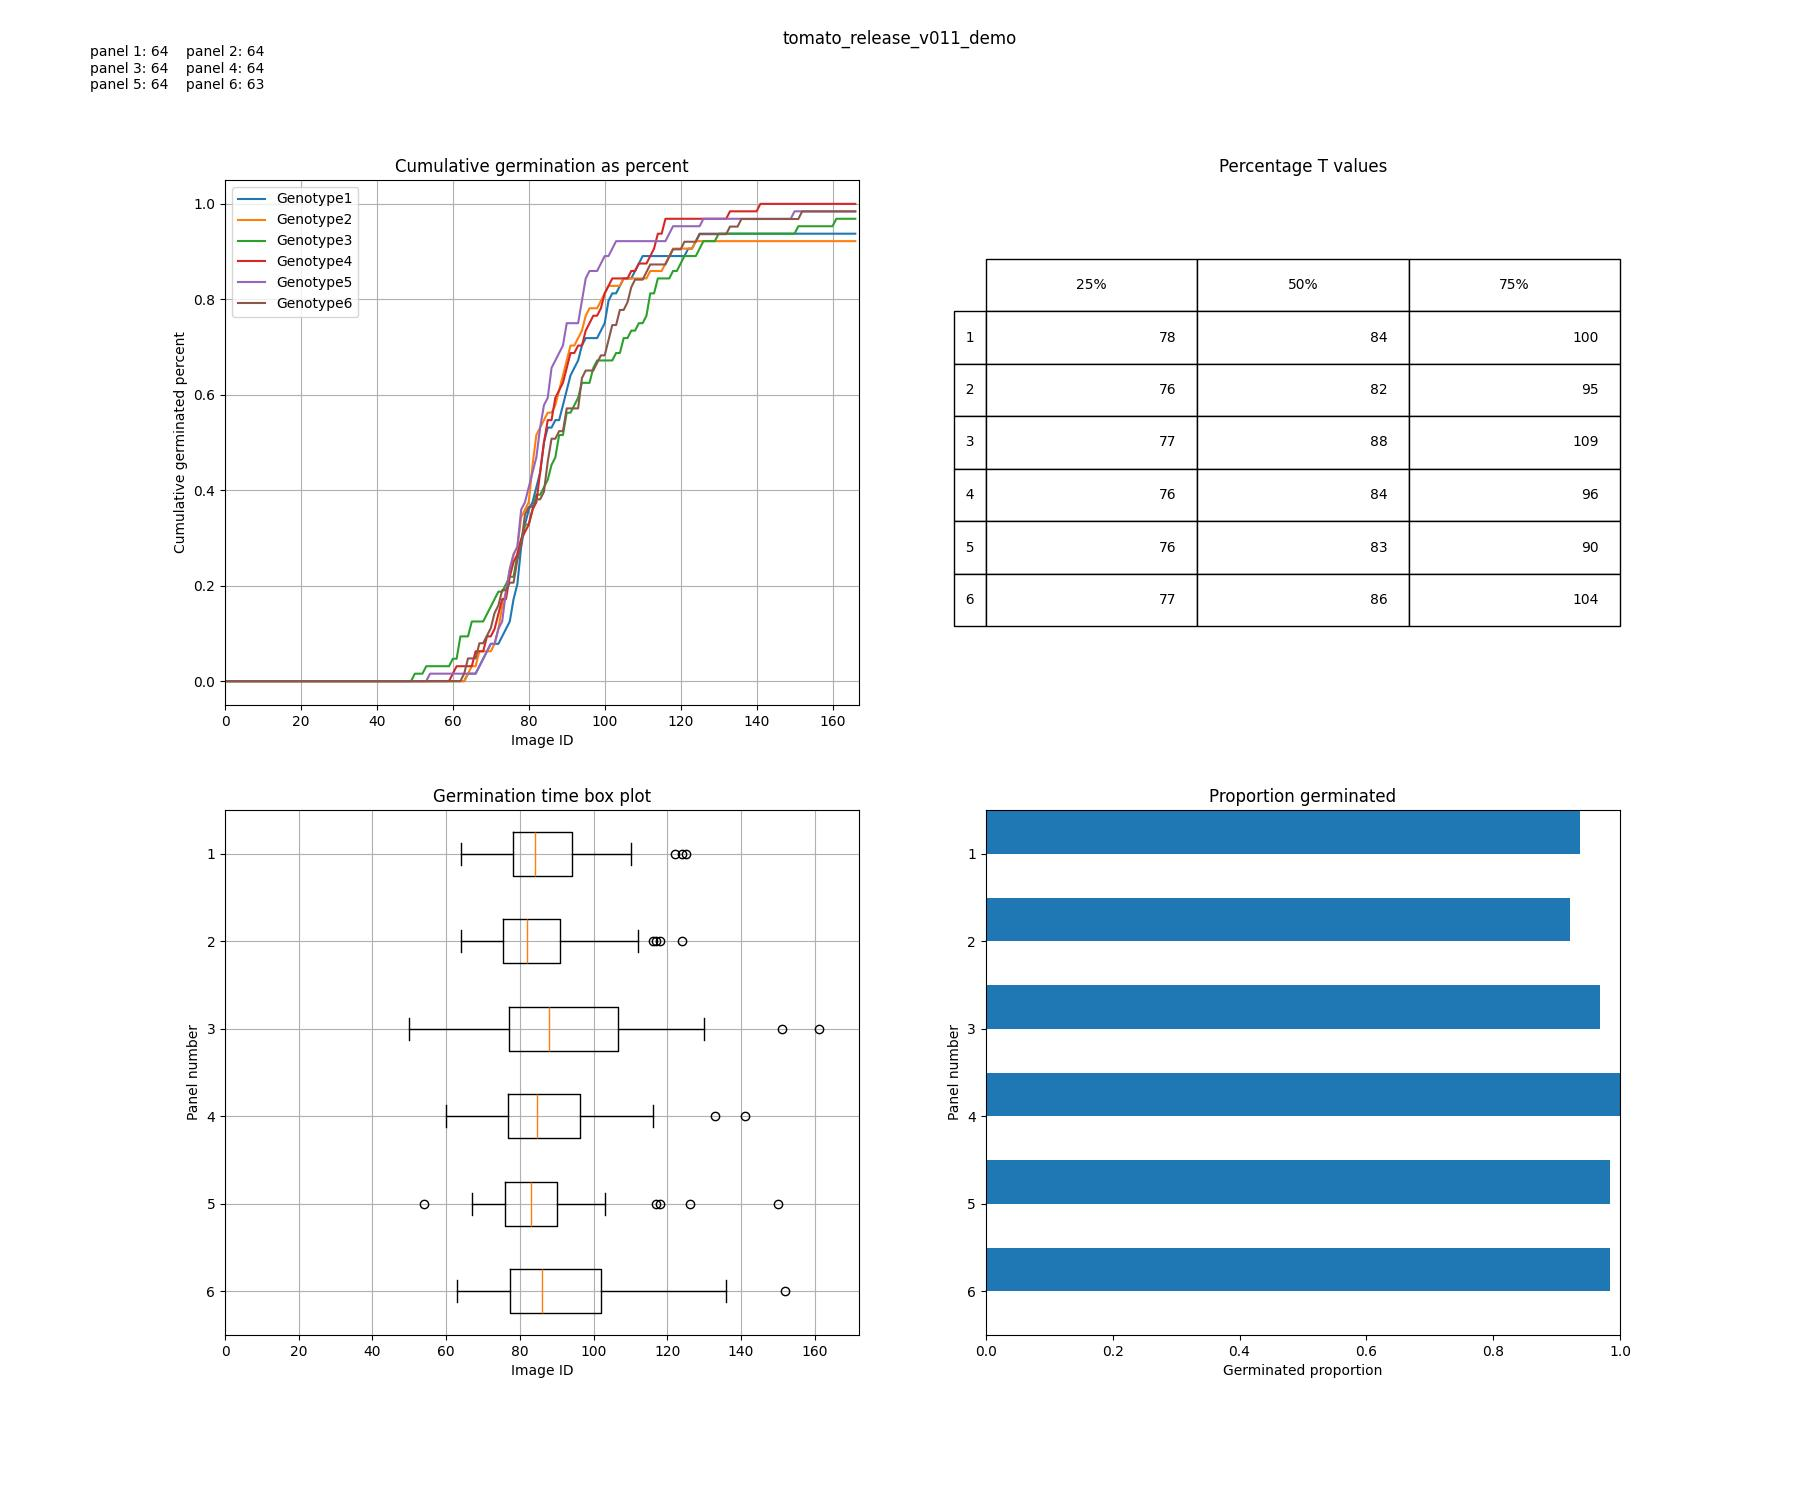

,1,2,3,4,5,6
165,60.0,59.0,62.0,64.0,63.0,62.0
166,60.0,59.0,62.0,64.0,63.0,62.0
Total seeds,64.0,64.0,64.0,64.0,64.0,63.0


,panel_ID,total_seeds,avg_width,avg_height,avg_wh_ratio,avg_area,avg_eccentricity,avg_initial_rgb,avg_final_rgb,germ_25%,germ_50%,germ_75%,total_germ_%
0,1,63,33.05,30.48,1.16,546.59,0.77,"(np.int32(222), np.int32(172), np.int32(69))","(np.int32(184), np.int32(156), np.int32(136))",81,88,103,0.95
1,2,66,34.03,35.94,1.04,601.68,0.78,"(np.int32(215), np.int32(159), np.int32(58))","(np.int32(182), np.int32(152), np.int32(113))",79,85,99,0.89
2,3,65,25.18,26.46,1.05,372.00,0.79,"(np.int32(211), np.int32(162), np.int32(64))","(np.int32(180), np.int32(156), np.int32(136))",81,93,115,0.95
3,4,64,30.16,32.42,1.01,547.80,0.73,"(np.int32(222), np.int32(172), np.int32(65))","(np.int32(181), np.int32(156), np.int32(130))",81,88,99,1.00
4,5,64,32.95,37.08,1.00,574.44,0.78,"(np.int32(212), np.int32(155), np.int32(50))","(np.int32(182), np.int32(148), np.int32(102))",79,86,97,0.98
5,6,65,26.17,25.26,1.13,371.28,0.80,"(np.int32(207), np.int32(155), np.int32(59))","(np.int32(178), np.int32(154), np.int32(138))",82,93,109,0.95


,panel_ID,seed_ID,width,height,wh_ratio,area,eccentricity,germ_point,germ_image_number
0,1,1,21,39,0.54,432,0.82,85.0,85.0
1,1,2,44,32,1.38,856,0.87,87.0,87.0
2,1,3,36,32,1.12,570,0.85,71.0,71.0
3,1,4,24,29,0.83,459,0.66,92.0,92.0
4,1,5,42,32,1.31,637,0.85,NaN,NaN
5,1,6,35,20,1.75,255,0.97,82.0,82.0
6,1,7,41,34,1.21,777,0.62,84.0,84.0
7,1,8,24,47,0.51,609,0.85,91.0,91.0


panel_results.csv rows: 387 | germinated: 370


In [ ]:
# Cell 8 — Show the author's results figure and output tables
from IPython.display import Image, display
import pandas as pd, glob

res_dir = os.path.join(EXP_PATH, "results")
print("output files:", sorted(os.path.basename(p) for p in glob.glob(res_dir + "/*")))

fig_path = os.path.join(res_dir, "results.jpg")
if os.path.exists(fig_path):
    display(Image(fig_path, width=900))
else:
    print("results.jpg not produced")

cum = pd.read_csv(os.path.join(res_dir, "panel_germinated_cumulative.csv"), index_col=0)
display(cum.tail(3))

overall = pd.read_csv(os.path.join(res_dir, "overall_results.csv"))
display(overall)

panel_res = pd.read_csv(os.path.join(res_dir, "panel_results.csv"))
display(panel_res.head(8))
print("panel_results.csv rows:", len(panel_res),
      "| germinated:", int((panel_res['germ_point'] >= 0).sum()))

### Cumulative germination (re-plotted) / 累積発芽曲線の再描画

A compact re-plot of `panel_germinated_cumulative.csv` — an **additional visualization created for this notebook** (the authors' own figure is `results.jpg` above), one line per panel/genotype.

**（JP）** `panel_germinated_cumulative.csv` を本ノートブック用に簡潔に再描画したものです（著者の図は上の results.jpg）。

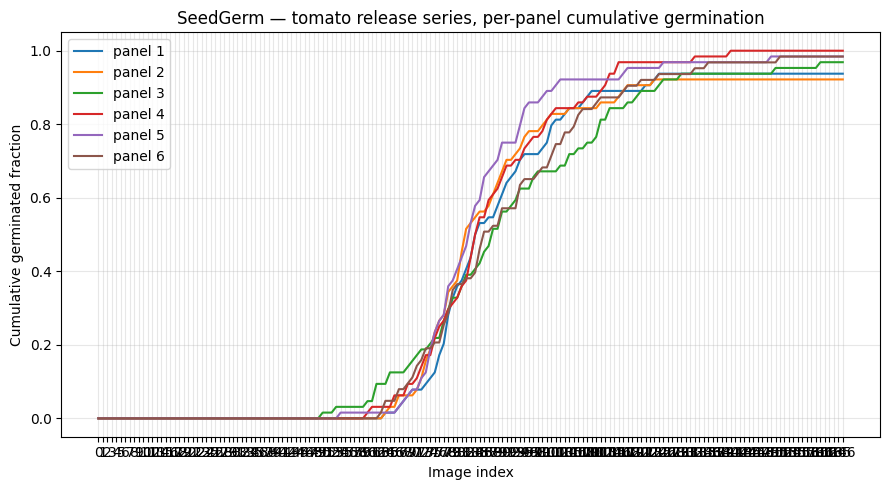

CSV available for download: /content/seedgerm_experiment/results/panel_germinated_cumulative.csv


In [ ]:
# Cell 9 — Compact cumulative-germination plot + CSV export
import matplotlib.pyplot as plt

cum = pd.read_csv(os.path.join(EXP_PATH, "results", "panel_germinated_cumulative.csv"), index_col=0)
totals = cum.loc["Total seeds"].astype(float)
plot_df = cum.drop(index="Total seeds").astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
for col in plot_df.columns:
    ax.plot(plot_df.index, plot_df[col] / totals[col], label=f"panel {col}")
ax.set_xlabel("Image index" + (" (frame subsample)" if est_total > MEM_BUDGET else ""))
ax.set_ylabel("Cumulative germinated fraction")
ax.set_title("SeedGerm — tomato release series, per-panel cumulative germination")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

export = os.path.join(EXP_PATH, "results", "panel_germinated_cumulative.csv")
print("CSV available for download:", export)

## Interpretation and validation record / 解釈と検証記録

- **What was executed:** the authors' pinned pipeline (commit `41eac87598fc97eeecc1e6c41bb65e30434e9688`) end-to-end on the released tomato series — panel segmentation, GMM background removal (author default) trained on YUV-labelled pixels, per-seed tracking, one-class-SVM germination classification (Tomato defaults: `nu=0.03, kernel=rbf, gamma=0.001`, trained on the first 20% of frames; onset = first frame with area > 1.25× initial mean area), and SeedGerm's cumulative-germination smoothing (win=4) and CSV outputs.
- **Substitutions (all documented above):** interactive YUV slider → Otsu V-low (verified with the GUI's own acceptance criterion); optional deterministic frame subsampling for memory; display-only DPI/patch changes. **AI-assisted adaptation; the authors did not provide this headless implementation.** Untested behaviour is not guaranteed. 実行結果は著者コードに明示的な置換（GUIしきい値の自動選択等）を施したものであり、著者提供の実装ではありません。
- **Scope limits:** a single released series; no dataset-level accuracy claims (paper Table 1 correlations are not recomputed); U-Net exploratory path not used (no public weights); Notes S1–S4 / Datasets S1–S11 have no working retrieval URLs (per investigation). 1例の実行であり、論文のデータセット全体の精度検証ではありません。
- **Provenance:** code github.com/Crop-Phenomics-Group/SeedGerm@41eac87; data release v0.1.1 `Tomato.zip` (590,621,487 bytes, verified). Paper: New Phytologist 228(2):778–793 (2020), DOI 10.1111/nph.16736 (accepted-article version studied via OpenAlex-cached copy).

## References / 参考文献
1. Colmer J. et al. (2020) New Phytologist 228(2):778–793. doi:10.1111/nph.16736
2. SeedGerm repository (pinned `41eac87`): https://github.com/Crop-Phenomics-Group/SeedGerm
3. SeedGerm release v0.1.1: https://github.com/Crop-Phenomics-Group/SeedGerm/releases/tag/v0.1.1

In [ ]:
# Cell 10 — Record measured environment / 実測環境の記録
import platform, sklearn, skimage
print("python:", platform.python_version())
print("sklearn:", sklearn.__version__, "| skimage:", skimage.__version__)
print("completed:", time.strftime("%Y-%m-%d %H:%M:%S UTC", time.gmtime()))

python: 3.13.15
sklearn: 1.6.1 | skimage: 0.25.2
completed: 2026-10-03 00:45:00 UTC
